# Notebook 01 - Analisi preliminare del dataset

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [53]:
sns.set_theme(style='whitegrid')

### Caricamento dati

In [54]:
cust_path='../data/raw/olist_customers_dataset.csv'
geo_path='../data/raw/olist_geolocation_dataset.csv'
order_items_path='../data/raw/olist_order_items_dataset.csv'
order_paym_path='../data/raw/olist_order_payments_dataset.csv'
order_rev_path='../data/raw/olist_order_reviews_dataset.csv'
orders_path='../data/raw/olist_orders_dataset.csv'
product_path='../data/raw/olist_products_dataset.csv'
sellers_path='../data/raw/olist_sellers_dataset.csv'
prod_cat_name_path='../data/raw/product_category_name_translation.csv'

In [55]:
cust=pd.read_csv(cust_path)
geo=pd.read_csv(geo_path)
order_items=pd.read_csv(order_items_path)
order_payment=pd.read_csv(order_paym_path)
order_rev=pd.read_csv(order_rev_path)
order=pd.read_csv(orders_path)
product=pd.read_csv(product_path)
seller=pd.read_csv(sellers_path)
product_cat_name=pd.read_csv(prod_cat_name_path)

## Funzioni helper

In [56]:
def mostra_mancanti(data):
    miss=pd.DataFrame({
        "N_mancanti": data.isna().sum(),
        "%":(data.isna().mean()*100 ).round(2)
    })
    miss=miss[miss["N_mancanti"]>0].sort_values('N_mancanti',ascending=False)
    if miss.empty:
        print('Nessun Valore Mancante')
    else:
        display(miss)

In [57]:
def analisi_prel(data,nome):
    data.info()
    display(data.head())
    mostra_mancanti(data)
    print(f"Righe duplicate: {data.duplicated().sum()}")

### Analisi tabella CUSTOMERS

In [58]:
analisi_prel(cust,'Customers')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Nessun Valore Mancante
Righe duplicate: 0


In [59]:
cust['customer_unique_id'].nunique()

96096

In [60]:
cust['customer_id'].nunique()

99441

Sintesi 
#### DIMENSIONE  
Ogni riga contiene un cliente, la chiave unica di collegamento con le altre tabelle è 'customer_id', mentre customer_unique_id è l'identificativo del cliente, se un cliente effettua piu ordini avrà un customer_id diverso ma lo stesso customer_unique_id. Non sono presenti righe duplicate e nessun valore mancante.

- customer_id: codice identificativo del cliente, primary key e chiave di collegamento con le altre tabelle. Può comparire su più righe
- customer_unique_id: è l'identificativo della persona reale, esiste un solo identificativo
- customer_zip_code_prefix: codice postale del cliente
- customer_city: città del cliente
- customer_state: stato del cliente



### Analisi tabella GEOLOCATION

In [61]:
analisi_prel(geo,'Geolocation')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


Nessun Valore Mancante
Righe duplicate: 261831


In [62]:
geo_clean=geo.drop_duplicates()

In [63]:
geo_clean.shape

(738332, 5)

In [64]:
geo_clean['geolocation_city'].unique()

array(['sao paulo', 'são paulo', 'sao bernardo do campo', ..., 'ciríaco',
       'estação', 'vila lângaro'], dtype=object)

In [65]:
geo_clean['geolocation_city'].nunique()

8011

Sintesi 
#### DIMENSIONE  
Ogni riga rappresenta una coordinata della città con il relativo codice postale. ci sono 261831 righe duplicate, rindodante quindi saranno eliminate. La colonna che rapressenta la cità ha un problema di scrittura, ci sono stesse città ma scitte diversamente, come Sao Paulo e São Paulo con 8011 città distinte. Non ci sono valori mancanti. La variabile geolocation_zip_code_prefix si può collegare alla tabella sellers e customers, ma con un limite, avremo più punti sovrapposti, ottimo per un analisi di business suddiviso a zona.

- geolocation_zip_code_prefix: codice postale 
- geolocation_lat: latitudine 
- geolocation_lng: longitudine
- geolocation_city: città
- geolocation_state: stato



### Analisi ORDER_ITEMS

In [66]:
analisi_prel(order_items,'Ordini items')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


Nessun Valore Mancante
Righe duplicate: 0


In [67]:
order_items['order_id'].nunique()

98666

In [68]:
order_items[order_items['order_id']=='001d8f0e34a38c37f7dba2a37d4eba8b']

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
48,001d8f0e34a38c37f7dba2a37d4eba8b,1,e67307ff0f15ade43fcb6e670be7a74c,f4aba7c0bca51484c30ab7bdc34bcdd1,2017-05-18 17:35:11,18.99,7.78
49,001d8f0e34a38c37f7dba2a37d4eba8b,2,e67307ff0f15ade43fcb6e670be7a74c,f4aba7c0bca51484c30ab7bdc34bcdd1,2017-05-18 17:35:11,18.99,7.78


Sintesi
#### FATTO
Ogni riga della tabella rapresenta l'ordine con riferimento al prodotto acquistato, venditore, prezzo e costo consegna. Ci sono righe con lo stesso order_id, significa che ci sono più prodotti nel carello del cliente quindi un raggruppamento per order_id con somma del prezzo e della consegna.

- order_id: identificatore dell'ordine, ma non è unico (98666 distinti con 112650 di righe).
- order_item_id: contatore progressivo dei prodotti acquistati nell'ordine
- product_id: identificatore prodotto, collegamento a product
- seller_id: indentificatore venditore
- shipping_limit_date: data che rappresenta il limite di consegna
- price: prezzo del prodotto
- freight_value: costo di consegna


### ANALISI ORDER PAYMENTS

In [69]:
analisi_prel(order_payment,'Order Payment')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


Nessun Valore Mancante
Righe duplicate: 0


In [70]:
order_payment.groupby('order_id')['payment_sequential'].max().reset_index().sort_values('payment_sequential',ascending=False).head(30)

,order_id,payment_sequential
97261,fa65dad1b0e818e3ccc5cb0e39231352,29
79611,ccf804e764ed5650cd8759557269dc13,26
15577,285c2e15bebd4ac83635ccc563dc71f4,22
53168,895ab968e7bb0d5659d16cd74cd1650c,21
92724,ee9ca989fc93ba09a6eddc250ce01742,19
99020,fedcd9f7ccdc8cba3a18defedd1a5547,19
29586,4bfcba9e084f46c8e3cb49b0fa6e6159,15
12924,21577126c19bf11a0b91592e5844ba78,15
27411,4689b1816de42507a7d63a4617383c59,14
23431,3c58bffb70dcf45f12bdf66a3c215905,14


In [71]:
order_payment[order_payment['order_id']=='fa65dad1b0e818e3ccc5cb0e39231352'].sort_values('payment_sequential')

,order_id,payment_sequential,payment_type,payment_installments,payment_value
14321,fa65dad1b0e818e3ccc5cb0e39231352,1,voucher,1,3.71
23074,fa65dad1b0e818e3ccc5cb0e39231352,2,voucher,1,8.51
65641,fa65dad1b0e818e3ccc5cb0e39231352,3,voucher,1,2.95
9985,fa65dad1b0e818e3ccc5cb0e39231352,4,voucher,1,29.16
28330,fa65dad1b0e818e3ccc5cb0e39231352,5,voucher,1,0.66
29648,fa65dad1b0e818e3ccc5cb0e39231352,6,voucher,1,5.02
82593,fa65dad1b0e818e3ccc5cb0e39231352,7,voucher,1,0.32
68853,fa65dad1b0e818e3ccc5cb0e39231352,8,voucher,1,26.02
17274,fa65dad1b0e818e3ccc5cb0e39231352,9,voucher,1,1.08
19565,fa65dad1b0e818e3ccc5cb0e39231352,10,voucher,1,12.86


In [72]:
order_payment['order_id'].nunique()

99440

In [73]:
order_payment['order_id'][order_payment['payment_sequential']>1]

25        5cfd514482e22bc992e7693f0e3e8df7
75        3689194c14ad4e2e7361ebd1df0e77b0
102       21b8b46679ea6482cbf911d960490048
121       ea9184ad433a404df1d72fa0a8764232
139       82ffe097d8ddbf319a523b9bbe7725d5
                        ...               
103569    fedcd9f7ccdc8cba3a18defedd1a5547
103732    f0a5b7c94819c69d12a1c0458ec74756
103747    cf101c3abd3c061ca9f78c1bbb1125af
103750    d0bff47153ef056bb4f884a2ec2f0691
103860    31bc09fdbd701a7a4f9b55b5955b8687
Name: order_id, Length: 4526, dtype: object

In [74]:
order_payment[order_payment['order_id']=='5cfd514482e22bc992e7693f0e3e8df7']

,order_id,payment_sequential,payment_type,payment_installments,payment_value
25,5cfd514482e22bc992e7693f0e3e8df7,2,voucher,1,45.17
57742,5cfd514482e22bc992e7693f0e3e8df7,1,credit_card,4,665.41


In [75]:
order_payment['payment_type'].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

Sintesi
#### FATTO
Ogni riga della tabella rappresenta il metodo di pagamento e il costo pagato in sequenza. Non ci sono valori mancanti e righe duplicate.
Bisognerà aggregare per codice ordine, sommare su payment_value e ragionare su payment_sequential, payment_type, payment_installments, poichè non posso sommare su payment_type, non avrebbe senso, magari potrei usare una flag per il metodo di pagamento.

- order_id: codice ordine che si collega alla tabella order_item, order_rev. Non è unica.
- payment_sequential: il numero sequenziale del metodo di pagamento utilizzato per saldare un singolo ordine
- payment_type: come ha pagato il cliente
- payment_installments: numero di rate concordate
- payment_value: valore pagato

### Analisi Tabella Order Review

In [76]:
analisi_prel(order_rev,'Order Review')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


,N_mancanti,%
review_comment_title,87656,88.34
review_comment_message,58247,58.70


Righe duplicate: 0


In [77]:
order_rev['review_comment_title'].value_counts()

review_comment_title
Recomendo                    423
recomendo                    345
Bom                          293
super recomendo              270
Excelente                    248
                            ... 
Luminaria sobrepor led 18      1
Não recebi.                    1
produto com lacre violado      1
Atraso Entrega                 1
Foto enganosa                  1
Name: count, Length: 4527, dtype: int64

In [78]:
order_rev['review_comment_message'].value_counts()

review_comment_message
Muito bom                                                                                                                                                                                              230
Bom                                                                                                                                                                                                    189
muito bom                                                                                                                                                                                              122
bom                                                                                                                                                                                                    107
Recomendo                                                                                                                                                            

In [79]:
order_rev[['review_id','order_id']].nunique()

review_id    98410
order_id     98673
dtype: int64

In [80]:
order_rev_m=order_rev.groupby('review_id').size().rename('N').reset_index()

In [81]:
order_rev_m[order_rev_m['N']>1]

,review_id,N
31,00130cbe1f9d422698c812ed8ded1919,2
425,0115633a9c298b6a98bcbe4eee75345f,2
568,0174caf0ee5964646040cd94e15ac95e,2
574,017808d29fd1f942d97e50184dfb4c13,2
884,0254bd905dc677a6078990aad3331a36,2
...,...,...
97594,fde2e6abaf5bb64f7407a44741c24dec,2
97601,fde5986d35c89aa1b6ce4149de82a0d3,2
97794,fe5c833752953fed3209646f1f63b53c,2
98105,ff2fc9e68f8aabfbe18d710b83aabd30,2


In [82]:
order_rev[order_rev['review_id']=='0174caf0ee5964646040cd94e15ac95e']

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
57280,0174caf0ee5964646040cd94e15ac95e,74db91e33b4e1fd865356c89a61abf1f,1,NaN,Produto entregue dentro de embalagem do fornec...,2018-03-07 00:00:00,2018-03-08 03:00:53
92876,0174caf0ee5964646040cd94e15ac95e,f93a732712407c02dce5dd5088d0f47b,1,NaN,Produto entregue dentro de embalagem do fornec...,2018-03-07 00:00:00,2018-03-08 03:00:53


In [83]:
order_rev_m2=order_rev.groupby('order_id').size().rename('N').reset_index()
order_rev_m2[order_rev_m2['N']>1]

,order_id,N
84,0035246a40f520710769010f752e7507,2
461,013056cfe49763c6f66bda03396c5ee3,2
556,0176a6846bcb3b0d3aa3116a9a768597,2
835,02355020fd0a40a0d56df9f6ff060413,2
985,029863af4b968de1e5d6a82782e662f5,2
...,...,...
97779,fd95ae805c63c534f1a64589e102225e,2
97943,fe041ba1c9f54016432fa6ee91709dbc,2
98480,ff763b73e473d03c321bcd5a053316e8,2
98497,ff850ba359507b996e8b2fbb26df8d03,2


In [84]:
order_rev[order_rev['order_id']=='0035246a40f520710769010f752e7507']

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
22423,2a74b0559eb58fc1ff842ecc999594cb,0035246a40f520710769010f752e7507,5,NaN,Estou acostumada a comprar produtos pelo barat...,2017-08-25 00:00:00,2017-08-29 21:45:57
25612,89a02c45c340aeeb1354a24e7d4b2c1e,0035246a40f520710769010f752e7507,5,NaN,NaN,2017-08-29 00:00:00,2017-08-30 01:59:12


Sintesi  
#### FATTO
Le righe della tabella rappresentano le recensioni degli ordini. Non ci sono righe duplicate, ma due colonne hanno dei valori mancanti: revie_comment_title e revie_comment_message, questo è dovuto alla mancanza di un titolo o un commenso, situazione che capita molto spesso.
- review_id: identificativo della recensione (ma non unico)
- order_id: chiave esterna, si collega alle tabelle order_items, order_payments, orders
- review_score: punteggio recensione
- review_comment_title: titolo recensione
- review_comment_message: commento recensione
- review_creation_date: data creazione recensione
- review_answer_timestamp: data risposta recensione    
  
 Nota: Si è notato che ci sono due casi da esaminare in seguito, in base all'analisi che bisogna fare:
1) Esaminando i valori unici di order_id (98673) differente dal numero totale di righe della tabella (99224), si è riscontrato che ci sono stessi codici ordine ma con due codici di recensione differenti
2) Esainando i valori unici di review_id (98410) differente dal numero totale di righe della tabella (99224), si è riscontrato che ci sono stessi codici recensione ma con due codici di ordine differenti

### Analisi Tabella Order

In [85]:
analisi_prel(order,'Orders')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


,N_mancanti,%
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
order_approved_at,160,0.16


Righe duplicate: 0


In [86]:
order['order_purchase_timestamp']=pd.to_datetime(order['order_purchase_timestamp'])

In [87]:
print(f'Prima data di acquisto: {order["order_purchase_timestamp"].min()}')
print(f'Ultima data di acquisto: {order["order_purchase_timestamp"].max()}')

Prima data di acquisto: 2016-09-04 21:15:19
Ultima data di acquisto: 2018-10-17 17:30:18


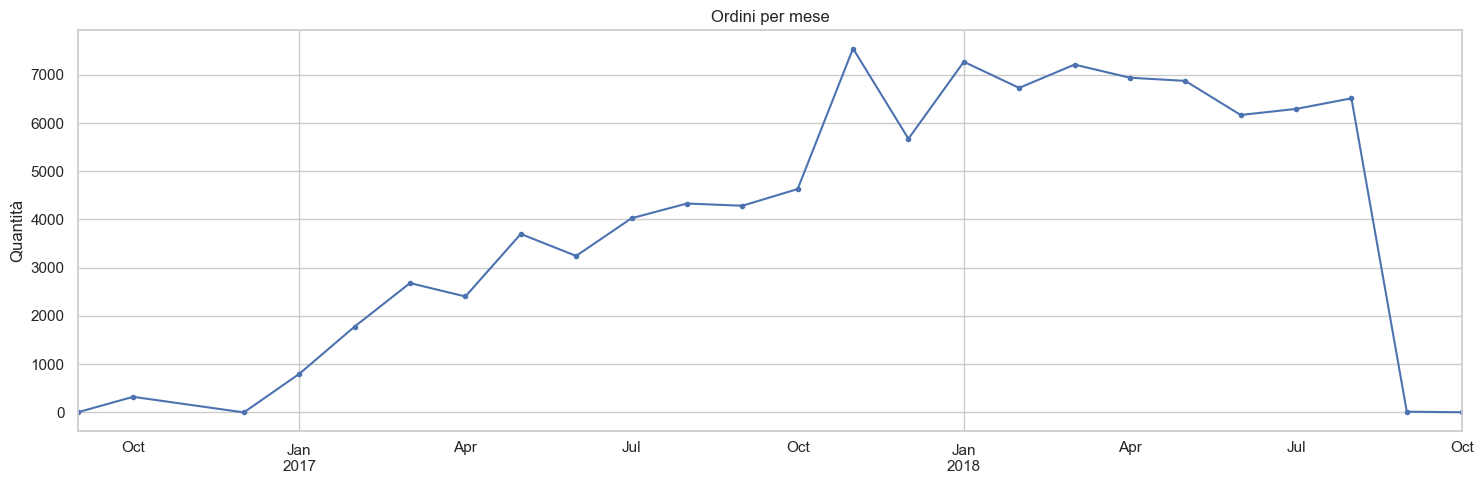

In [88]:
fig,ax=plt.subplots(figsize=(15,5))
order['order_purchase_timestamp'].dt.to_period('M').value_counts().sort_index().plot(kind='line',marker='.',ax=ax)
ax.set_title('Ordini per mese')
ax.set_xlabel(''); ax.set_ylabel('Quantità')
plt.tight_layout();plt.show()

Andamento vendite in crescita dal 2016-09 con picco nel 2017-10 e discesa fino all'ultimo giorno osservabile 2018-10-17.

In [89]:
order[['order_id','customer_id']].nunique()

order_id       99441
customer_id    99441
dtype: int64

In [90]:
order['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [91]:
order[order['order_delivered_customer_date'].isna()]['order_status'].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

In [92]:
order[(order['order_delivered_customer_date'].isna()) & (order['order_status']=='delivered')]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaN,2017-12-18 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaN,2018-07-16 00:00:00
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaN,2018-07-24 00:00:00
92643,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaN,NaN,2017-06-23 00:00:00
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaN,2018-06-26 00:00:00
98038,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaN,2018-07-19 00:00:00


In [93]:
order[(order['order_delivered_carrier_date'].isna())]['order_status'].value_counts()

order_status
unavailable    609
canceled       550
invoiced       314
processing     301
created          5
approved         2
delivered        2
Name: count, dtype: int64

In [94]:
order[(order['order_approved_at'].isna())]['order_status'].value_counts()

order_status
canceled     141
delivered     14
created        5
Name: count, dtype: int64

Sintensi Ordini
#### FATTO
Ogni riga rappresenta un ordine. Non ci sono righe duplicate, ma ci sono valori mancanti:  
order_delivered_customer_date con 2965 valori mancanti (2.98%), order_delivered_carrier_date con 1783 valori mancanti (1.79) e order_approved_at con 160 (0.16). Dovuti al fatto che non sono stati ancora consegnati e/o cancellati.
C'è una contraddizione nei valori mancanti alcuni sono stati consegnati ma non hanno una data di consegna, quindi errore di qualità.

- order_id: chiave unica di questa tabella (PK), identifictore ordine
- customer_id: chiave esterna che si collega alla tabella customers, identificativo del cliente
- order_status: stato dell'ordine
- order_purchase_timestamp: data di acquisto 
- order_approved_at: data di approvazione ordine
- order_delivered_carrier_date: data di rilascio al corriere
- order_delivered_customer_date: data di consegna al cliente
- order_estimated_delivery_date: data stimata di consegna

###  Analisi Tabella Product

In [95]:
analisi_prel(product,'Product')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


,N_mancanti,%
product_category_name,610,1.85
product_name_lenght,610,1.85
product_description_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01


Righe duplicate: 0


In [96]:
product['product_category_name'].nunique()

73

In [97]:
product['product_id'].nunique()

32951

In [98]:
product[product['product_category_name'].isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


In [99]:
product.groupby('product_id').size().max()


1

Sintensi  
#### DIMENSIONE
Ogni riga rappresenta un singolo prodotto con le sue caratteristiche. Non ci sono righe duplicate ma alcuni prodotti hanno valori mancanti, come product_category_name, product_name_lenght, product_description_lenght e product_photos_qty, la scelta è di lasciarle poichè posso essere prodotti venduti.
- product_id: chiave della tabella, identificatore del prodotto
- product_category_name: nome categoria prodotto
- product_name_lenght: lunghezza nome prodotto
- product_description_lenght: lunghezza descrizione prodotto
- product_photos_qty: quantità foto prodotto
- product_weight_g: peso in grammi del prodotto
- product_lenght_cm: lunghezza in cm del prodotto
- product_height_cm: altezza in cm del prodotto
- product_width_cm: larghezza in cm del prodotto

### Analisi Tabella Sellers

In [100]:
analisi_prel(seller,'Seller')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


Nessun Valore Mancante
Righe duplicate: 0


In [101]:
seller['seller_id'].nunique()

3095

Sintesi  
#### DIMENSIONE
Ogni riga rappresenta un venditore, non ci sono valori mancanti e righe duplicate.

- seller_id: chiave primaria per questa tabella, si collega alla tabella order_items.
- seller_zip_code_prefix: codice postale del venditore, chiave che si collega alla tabella geolocation
- seller_city: città del venditore
- seller_state: stato del venditore

### Analisi Tabella Categorie Prodotti

In [102]:
analisi_prel(product_cat_name,'Prodotti categorie e nomi')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


Nessun Valore Mancante
Righe duplicate: 0


Sintesi  
#### DIMENSIONE
Ogni riga rappresenta una categoria in lingua portoghese e tradotto in inglese, non ci sono valori mancanti e righe duplicate, si collega a product tramite product_category_name.

- product_category_name: nome categoria prodotto in lingua portoghese
- product_category_name_english: nome categoria prodotto in inglese